# PROJET NLP & INFORMATION RETRIEVAL BY BOULMIER Ilan & COLIN De Verdière Thomas 

## Partie IV : Model

Cette Partie couvre :
1. TF-IDF + modèles ML classiques (Logistic Regression, SVM, Random Forest)
2. Modèle avec couche d'embedding entraînable (Keras)
3. Modèle avec embeddings pré-entraînés Word2Vec
4. BERT (CamemBERT pour le français)
5. LLM (zero-shot avec HuggingFace)
6. Comparaison de tous les modèles

## 0. Imports et configuration

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score)
from sklearn.preprocessing import LabelEncoder
import warnings, os, time
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

# Résultats globaux pour comparaison finale
results_comparison = {}

print('✅ Imports de base OK')

✅ Imports de base OK


## 1. Chargement et préparation des données

In [11]:
df_train = pd.read_csv('avis_train_clean.csv')
df_test  = pd.read_csv('avis_test_clean.csv')

# Supprimer les lignes sans texte
df_train = df_train.dropna(subset=['avis_clean', 'note']).reset_index(drop=True)

# Cibles
# Tâche 1 : prédire la note (1-5) → 5 classes
# Tâche 2 : prédire le sentiment (3 classes) → plus simple
y_note      = df_train['note'].astype(int)
y_sentiment = df_train['sentiment_3']  # negatif / neutre / positif

# On travaille sur le sentiment 3 classes (plus équilibré et pédagogique)
# Changez y_sentiment par y_note pour prédire 1-5 étoiles
TARGET = 'sentiment_3'
y = df_train[TARGET]

# Encodage des labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f'Classes : {le.classes_}')
print(f'Distribution : {pd.Series(y).value_counts().to_dict()}')

# Split train / validation
X_train_text, X_val_text, y_train, y_val = train_test_split(
    df_train['avis_clean'], y_encoded,
    test_size=0.2, random_state=42, stratify=y_encoded
)

print(f'\nTrain : {len(X_train_text):,} | Validation : {len(X_val_text):,}')

Classes : ['negatif' 'neutre' 'positif']
Distribution : {'negatif': 10986, 'positif': 9734, 'neutre': 3382}

Train : 19,281 | Validation : 4,821


## 2. TF-IDF + Modèles ML classiques

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

# Vectorisation TF-IDF
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),   # unigrammes + bigrammes
    min_df=2,
    sublinear_tf=True     # log(tf) au lieu de tf brut
)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_val_tfidf   = tfidf.transform(X_val_text)

print(f'Matrice TF-IDF train : {X_train_tfidf.shape}')
print(f'Matrice TF-IDF val   : {X_val_tfidf.shape}')

Matrice TF-IDF train : (19281, 20000)
Matrice TF-IDF val   : (4821, 20000)


In [13]:
# Entraînement de plusieurs modèles classiques
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', C=1.0),
    'LinearSVC':           LinearSVC(max_iter=2000, class_weight='balanced', C=1.0),
    'Naive Bayes':         MultinomialNB(alpha=0.1),
    'Random Forest':       RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1),
}

print(f'{'Modèle':<25} {'Accuracy':>10} {'F1-macro':>10} {'Temps':>8}')
print('-' * 58)

for name, clf in classifiers.items():
    t0 = time.time()
    clf.fit(X_train_tfidf, y_train)
    y_pred = clf.predict(X_val_tfidf)
    acc = accuracy_score(y_val, y_pred)
    f1  = f1_score(y_val, y_pred, average='macro')
    elapsed = time.time() - t0
    print(f'{name:<25} {acc:>10.4f} {f1:>10.4f} {elapsed:>7.1f}s')
    results_comparison[f'TF-IDF + {name}'] = {'accuracy': acc, 'f1_macro': f1}

Modèle                      Accuracy   F1-macro    Temps
----------------------------------------------------------
Logistic Regression           0.7795     0.6791     2.7s
LinearSVC                     0.7830     0.6479     1.0s
Naive Bayes                   0.8102     0.6267     0.0s
Random Forest                 0.7946     0.5759    41.2s


=== Rapport de classification — Logistic Regression + TF-IDF ===
              precision    recall  f1-score   support

     negatif       0.86      0.88      0.87      2197
      neutre       0.32      0.34      0.33       677
     positif       0.86      0.82      0.84      1947

    accuracy                           0.78      4821
   macro avg       0.68      0.68      0.68      4821
weighted avg       0.78      0.78      0.78      4821



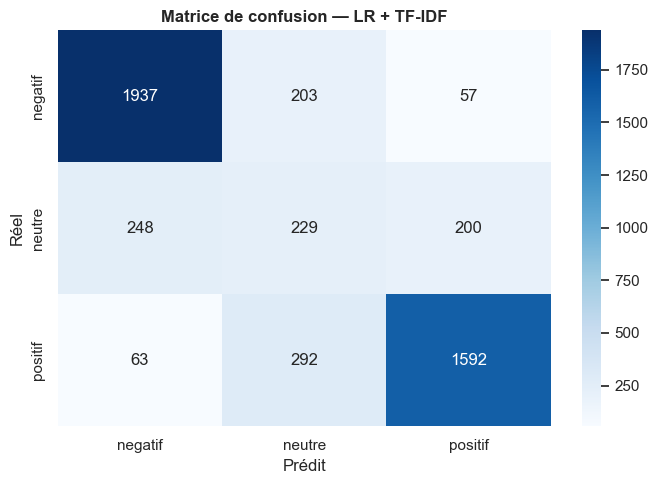

In [14]:
# Rapport détaillé du meilleur modèle classique (Logistic Regression)
best_clf = classifiers['Logistic Regression']
y_pred_lr = best_clf.predict(X_val_tfidf)

print('=== Rapport de classification — Logistic Regression + TF-IDF ===')
print(classification_report(y_val, y_pred_lr, target_names=le.classes_))

# Matrice de confusion
cm = confusion_matrix(y_val, y_pred_lr)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matrice de confusion — LR + TF-IDF', fontweight='bold')
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.tight_layout()
plt.savefig('confusion_tfidf_lr.png', dpi=150, bbox_inches='tight')
plt.show()

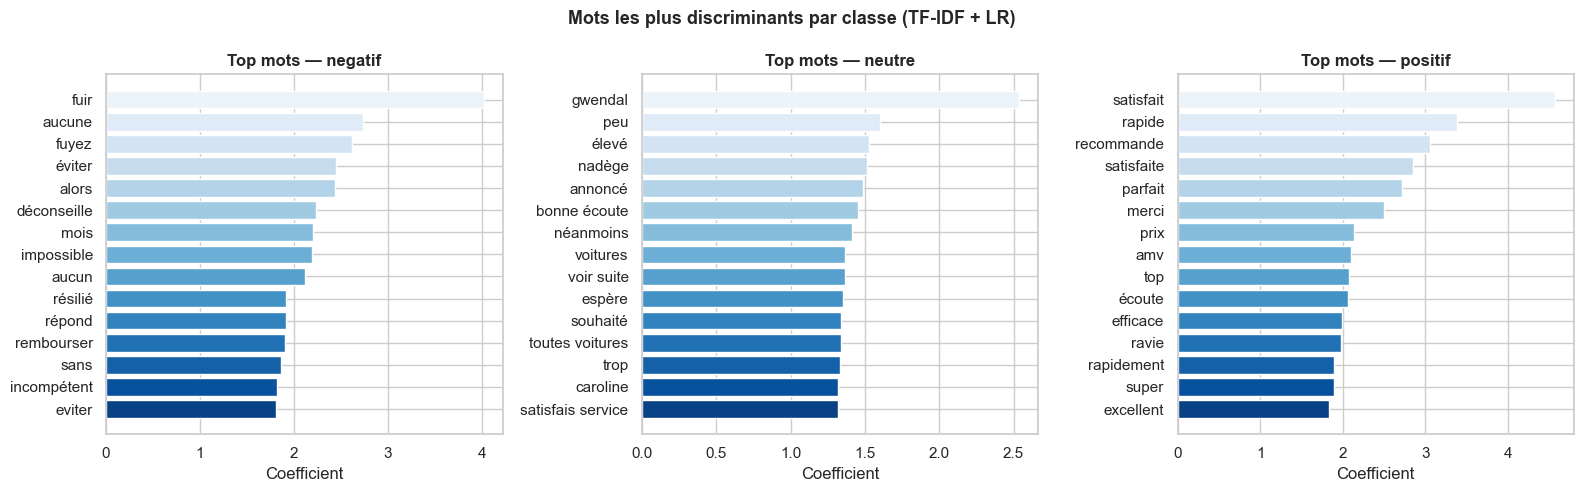

In [15]:
# Top features TF-IDF par classe
feature_names = tfidf.get_feature_names_out()
coefs = best_clf.coef_

fig, axes = plt.subplots(1, len(le.classes_), figsize=(16, 5))
for i, (ax, classe) in enumerate(zip(axes, le.classes_)):
    top_idx = coefs[i].argsort()[-15:][::-1]
    top_feat = [feature_names[j] for j in top_idx]
    top_vals = coefs[i][top_idx]
    ax.barh(top_feat[::-1], top_vals[::-1], color=sns.color_palette('Blues_r', 15))
    ax.set_title(f'Top mots — {classe}', fontweight='bold')
    ax.set_xlabel('Coefficient')

plt.suptitle('Mots les plus discriminants par classe (TF-IDF + LR)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('top_features_tfidf.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Modèle avec couche d'embedding entraînable (Keras)

In [16]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, GlobalAveragePooling1D,
                                      Dense, Dropout, LSTM, Conv1D,
                                      GlobalMaxPooling1D)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard

print(f'TensorFlow version : {tf.__version__}')

# Paramètres
VOCAB_SIZE  = 20000
MAX_LEN     = 100
EMBED_DIM   = 64
NUM_CLASSES = len(le.classes_)

# Tokenisation Keras
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_text)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train_text), maxlen=MAX_LEN, padding='post')
X_val_seq   = pad_sequences(tokenizer.texts_to_sequences(X_val_text),   maxlen=MAX_LEN, padding='post')

print(f'Séquences train : {X_train_seq.shape}')
print(f'Séquences val   : {X_val_seq.shape}')

TensorFlow version : 2.21.0
Séquences train : (19281, 100)
Séquences val   : (4821, 100)


In [17]:
# Modèle simple : Embedding + GlobalAveragePooling + Dense
def build_embedding_model(vocab_size, embed_dim, max_len, num_classes):
    model = Sequential([
        Embedding(vocab_size, embed_dim, input_length=max_len, name='embedding'),
        GlobalAveragePooling1D(),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model_embed = build_embedding_model(VOCAB_SIZE, EMBED_DIM, MAX_LEN, NUM_CLASSES)
model_embed.summary()

# Callbacks
early_stop = EarlyStopping(patience=3, restore_best_weights=True)
tb_callback = TensorBoard(log_dir='tensorboard_embedding_model', histogram_freq=1)

# Entraînement
history_embed = model_embed.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=15,
    batch_size=64,
    callbacks=[early_stop, tb_callback],
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
302/302 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.6818 - loss: 0.8007 - val_accuracy: 0.7372 - val_loss: 0.6899
Epoch 2/15
302/302 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.7851 - loss: 0.5928 - val_accuracy: 0.7915 - val_loss: 0.5736
Epoch 3/15
302/302 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.8082 - loss: 0.5282 - val_accuracy: 0.8106 - val_loss: 0.5318
Epoch 4/15
302/302 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8151 - loss: 0.5012 - val_accuracy: 0.7772 - val_loss: 0.5935
Epoch 5/15
302/302 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.8245 - loss: 0.4688 - val_accuracy: 0.8110 - val_loss: 0.5324
Epoch 6/15
302/302 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8319 - loss: 0.4454 - val_accuracy: 0.8168 - val_loss: 0.5328


151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy : 0.8106
F1-macro : 0.5809
              precision    recall  f1-score   support

     negatif       0.82      0.95      0.88      2197
      neutre       0.00      0.00      0.00       677
     positif       0.80      0.93      0.86      1947

    accuracy                           0.81      4821
   macro avg       0.54      0.63      0.58      4821
weighted avg       0.70      0.81      0.75      4821



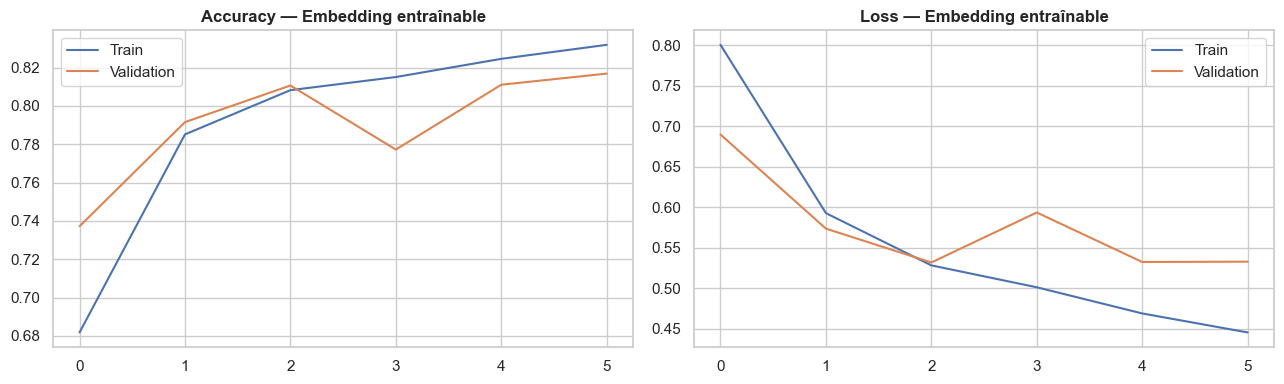

In [18]:
# Évaluation
y_pred_embed = model_embed.predict(X_val_seq).argmax(axis=1)
acc_embed = accuracy_score(y_val, y_pred_embed)
f1_embed  = f1_score(y_val, y_pred_embed, average='macro')
results_comparison['Embedding entraînable'] = {'accuracy': acc_embed, 'f1_macro': f1_embed}

print(f'Accuracy : {acc_embed:.4f}')
print(f'F1-macro : {f1_embed:.4f}')
print(classification_report(y_val, y_pred_embed, target_names=le.classes_))

# Courbes d'apprentissage
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history_embed.history['accuracy'], label='Train')
axes[0].plot(history_embed.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy — Embedding entraînable', fontweight='bold')
axes[0].legend()

axes[1].plot(history_embed.history['loss'], label='Train')
axes[1].plot(history_embed.history['val_loss'], label='Validation')
axes[1].set_title('Loss — Embedding entraînable', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('learning_curve_embed.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Modèle avec embeddings pré-entraînés (Word2Vec)

In [19]:
from gensim.models import Word2Vec

# Charger le modèle Word2Vec entraîné dans le notebook 03
w2v = Word2Vec.load('models/word2vec_avis.model')
wv  = w2v.wv

# Construire la matrice d'embedding à partir de Word2Vec
EMBED_DIM_W2V = 100  # dimension Word2Vec
word_index = tokenizer.word_index

embedding_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM_W2V))
covered = 0
for word, idx in word_index.items():
    if idx < VOCAB_SIZE and word in wv:
        embedding_matrix[idx] = wv[word]
        covered += 1

coverage = covered / min(len(word_index), VOCAB_SIZE) * 100
print(f'Couverture du vocabulaire par Word2Vec : {coverage:.1f}%')
print(f'({covered} mots sur {min(len(word_index), VOCAB_SIZE)} ont un vecteur)')

Couverture du vocabulaire par Word2Vec : 64.4%
(12877 mots sur 20000 ont un vecteur)


In [20]:
# Modèle avec embeddings Word2Vec figés
def build_pretrained_model(vocab_size, embed_dim, embedding_matrix, max_len, num_classes, trainable=False):
    model = Sequential([
        Embedding(
            vocab_size, embed_dim,
            weights=[embedding_matrix],
            input_length=max_len,
            trainable=trainable,   # False = figé, True = fine-tuning
            name='w2v_embedding'
        ),
        GlobalAveragePooling1D(),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model_w2v = build_pretrained_model(VOCAB_SIZE, EMBED_DIM_W2V, embedding_matrix, MAX_LEN, NUM_CLASSES)
model_w2v.summary()

tb_w2v = TensorBoard(log_dir='tensorboard_w2v_model', histogram_freq=1)

history_w2v = model_w2v.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=15,
    batch_size=64,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True), tb_w2v],
    verbose=1
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ w2v_embedding (Embedding)       │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,000,000 (7.63 MB)

Epoch 1/15
302/302 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7744 - loss: 0.6503 - val_accuracy: 0.8036 - val_loss: 0.5435
Epoch 2/15
302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8053 - loss: 0.5460 - val_accuracy: 0.8098 - val_loss: 0.5272
Epoch 3/15
302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8064 - loss: 0.5378 - val_accuracy: 0.8090 - val_loss: 0.5258
Epoch 4/15
302/302 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8083 - loss: 0.5271 - val_accuracy: 0.8096 - val_loss: 0.5143
Epoch 5/15
302/302 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8090 - loss: 0.5228 - val_accuracy: 0.8102 - val_loss: 0.5132
Epoch 6/15
302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8101 - loss: 0.5205 - val_accuracy: 0.8112 - val_loss: 0.5107
Epoch 7/15
302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8113 - loss: 0.5166 - val_accuracy: 0.8133 - val_loss: 0.5074
Epoch 8/15
302/302 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8122 - loss: 0.5142 - val_accuracy: 0.

In [21]:
# Évaluation
y_pred_w2v = model_w2v.predict(X_val_seq).argmax(axis=1)
acc_w2v = accuracy_score(y_val, y_pred_w2v)
f1_w2v  = f1_score(y_val, y_pred_w2v, average='macro')
results_comparison['Embedding Word2Vec pré-entraîné'] = {'accuracy': acc_w2v, 'f1_macro': f1_w2v}

print(f'Accuracy : {acc_w2v:.4f}')
print(f'F1-macro : {f1_w2v:.4f}')
print(classification_report(y_val, y_pred_w2v, target_names=le.classes_))

151/151 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Accuracy : 0.8131
F1-macro : 0.5965
              precision    recall  f1-score   support

     negatif       0.84      0.94      0.89      2197
      neutre       0.52      0.02      0.04       677
     positif       0.79      0.95      0.86      1947

    accuracy                           0.81      4821
   macro avg       0.72      0.64      0.60      4821
weighted avg       0.77      0.81      0.76      4821



## 5. CamemBERT (BERT français)

In [22]:
# pip install transformers torch
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                           TrainingArguments, Trainer)
import torch
from torch.utils.data import Dataset

print(f'PyTorch version : {torch.__version__}')
print(f'GPU disponible  : {torch.cuda.is_available()}')

# Modèle CamemBERT (BERT entraîné sur du texte français)
MODEL_NAME = 'camembert-base'
bert_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f'✅ Tokenizer CamemBERT chargé')

PyTorch version : 2.10.0+cpu
GPU disponible  : False
✅ Tokenizer CamemBERT chargé


In [23]:
# Dataset PyTorch
class AvisDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts     = list(texts)
        self.labels    = list(labels)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Utiliser un sous-ensemble pour accélérer (augmentez si vous avez un GPU)
BERT_SAMPLE = 3000
idx_sample = np.random.choice(len(X_train_text), BERT_SAMPLE, replace=False)
X_bert_train = X_train_text.iloc[idx_sample].reset_index(drop=True)
y_bert_train = y_train[idx_sample]

# Utiliser avis_clean_full (avec stopwords) pour BERT → contexte important
train_dataset = AvisDataset(X_bert_train, y_bert_train, bert_tokenizer)
val_dataset   = AvisDataset(X_val_text.reset_index(drop=True), y_val, bert_tokenizer)

print(f'Train BERT : {len(train_dataset)} | Val BERT : {len(val_dataset)}')

Train BERT : 3000 | Val BERT : 4821


In [24]:
# Chargement du modèle CamemBERT pour classification
bert_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES
)

# Arguments d'entraînement
training_args = TrainingArguments(
    output_dir='models/camembert_sentiment',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    evaluation_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    logging_dir='tensorboard_bert',
    logging_steps=50,
    warmup_ratio=0.1,
    weight_decay=0.01,
    fp16=torch.cuda.is_available(),  # Mixed precision si GPU
    report_to='tensorboard'
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    f1  = f1_score(labels, predictions, average='macro')
    return {'accuracy': acc, 'f1_macro': f1}

trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

print('Entraînement CamemBERT...')
print('⚠️  Sans GPU : ~20-30 min pour 3 epochs sur 3000 exemples')
trainer.train()

Some weights of CamembertForSequenceClassification were not initialized from the model checkpoint at camembert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Entraînement CamemBERT...
⚠️  Sans GPU : ~20-30 min pour 3 epochs sur 3000 exemples


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.664700,0.568796,0.795478,0.570149
2,0.561100,0.517994,0.810828,0.647545
3,0.490100,0.541451,0.810413,0.643378


TrainOutput(global_step=564, training_loss=0.5769541441126073, metrics={'train_runtime': 10700.7018, 'train_samples_per_second': 0.841, 'train_steps_per_second': 0.053, 'total_flos': 592005189888000.0, 'train_loss': 0.5769541441126073, 'epoch': 3.0})

In [25]:
# Évaluation CamemBERT
bert_results = trainer.evaluate()
acc_bert = bert_results['eval_accuracy']
f1_bert  = bert_results['eval_f1_macro']
results_comparison['CamemBERT'] = {'accuracy': acc_bert, 'f1_macro': f1_bert}

print(f'Accuracy CamemBERT : {acc_bert:.4f}')
print(f'F1-macro CamemBERT : {f1_bert:.4f}')

# Prédictions détaillées
preds_output = trainer.predict(val_dataset)
y_pred_bert = preds_output.predictions.argmax(axis=1)
print(classification_report(y_val, y_pred_bert, target_names=le.classes_))

Accuracy CamemBERT : 0.8108
F1-macro CamemBERT : 0.6475
              precision    recall  f1-score   support

     negatif       0.84      0.93      0.88      2197
      neutre       0.37      0.13      0.19       677
     positif       0.82      0.91      0.87      1947

    accuracy                           0.81      4821
   macro avg       0.68      0.66      0.65      4821
weighted avg       0.77      0.81      0.78      4821



## 6. LLM — Zero-shot avec HuggingFace

In [26]:
# Zero-shot classification avec un modèle pré-entraîné
# Pas besoin d'entraînement ! On utilise directement un LLM
from transformers import pipeline

# Modèle zero-shot multilingue
zero_shot = pipeline(
    'zero-shot-classification',
    model='facebook/bart-large-mnli',  # ou 'joeddav/xlm-roberta-large-xnli' pour multilingue
    device=0 if torch.cuda.is_available() else -1
)

# Labels candidats
candidate_labels = ['avis positif', 'avis neutre', 'avis négatif']

print('✅ Pipeline zero-shot chargé')
print(f'Modèle : facebook/bart-large-mnli')

Device set to use cpu


✅ Pipeline zero-shot chargé
Modèle : facebook/bart-large-mnli


In [27]:
# Évaluation sur un échantillon (zero-shot = lent sans GPU)
ZS_SAMPLE = 200
X_zs = X_val_text.iloc[:ZS_SAMPLE].tolist()
y_zs = y_val[:ZS_SAMPLE]

# Mapping des labels
label_map = {
    'avis positif': le.transform(['positif'])[0],
    'avis neutre':  le.transform(['neutre'])[0],
    'avis négatif': le.transform(['negatif'])[0]
}

print(f'Évaluation zero-shot sur {ZS_SAMPLE} exemples...')
y_pred_zs = []
for text in X_zs:
    result = zero_shot(str(text)[:512], candidate_labels)
    best_label = result['labels'][0]
    y_pred_zs.append(label_map[best_label])

acc_zs = accuracy_score(y_zs, y_pred_zs)
f1_zs  = f1_score(y_zs, y_pred_zs, average='macro')
results_comparison['LLM Zero-shot'] = {'accuracy': acc_zs, 'f1_macro': f1_zs}

print(f'\nAccuracy : {acc_zs:.4f}')
print(f'F1-macro : {f1_zs:.4f}')
print(classification_report(y_zs, y_pred_zs, target_names=le.classes_))

Évaluation zero-shot sur 200 exemples...

Accuracy : 0.7000
F1-macro : 0.5246
              precision    recall  f1-score   support

     negatif       0.71      0.80      0.75        94
      neutre       0.25      0.04      0.06        28
     positif       0.70      0.82      0.76        78

    accuracy                           0.70       200
   macro avg       0.56      0.55      0.52       200
weighted avg       0.65      0.70      0.66       200



## 7. Comparaison de tous les modèles

📊 COMPARAISON DE TOUS LES MODÈLES
                         Modèle  Accuracy  F1-macro
   TF-IDF + Logistic Regression  0.779506  0.679076
             TF-IDF + LinearSVC  0.783033  0.647896
                      CamemBERT  0.810828  0.647545
           TF-IDF + Naive Bayes  0.810205  0.626744
Embedding Word2Vec pré-entraîné  0.813109  0.596458
          Embedding entraînable  0.810620  0.580932
         TF-IDF + Random Forest  0.794648  0.575930
                  LLM Zero-shot  0.700000  0.524555


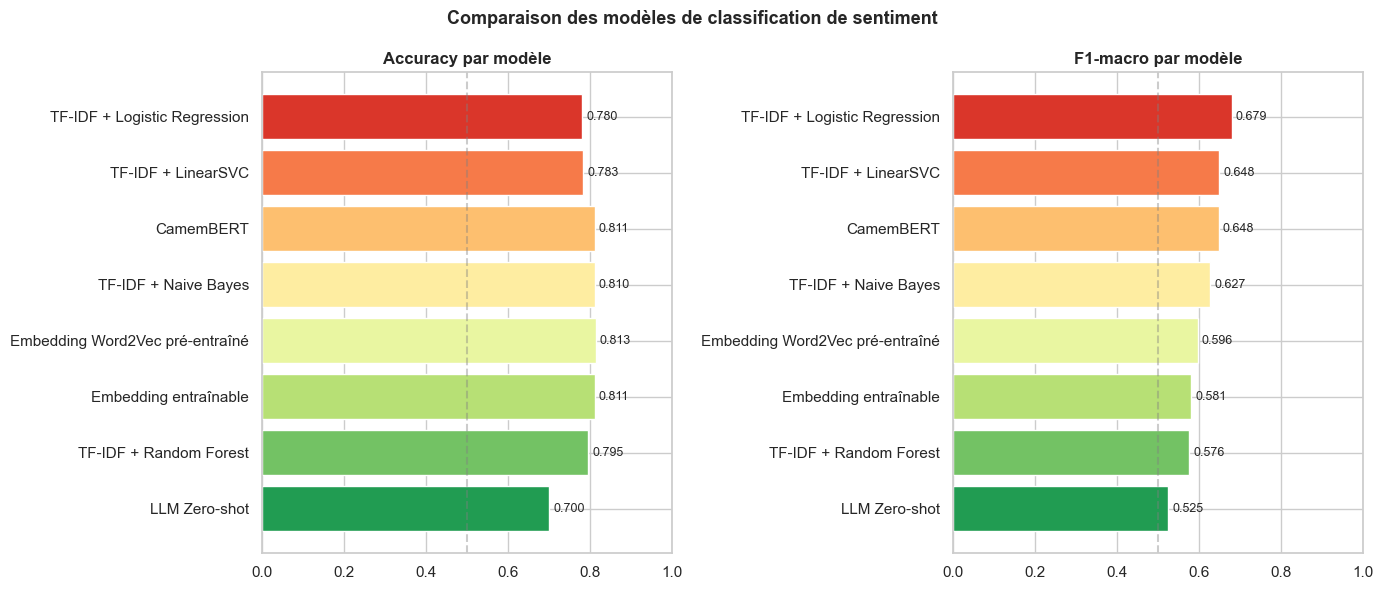


💾 Résultats sauvegardés : resultats_modeles.csv


In [30]:
# Tableau de comparaison final
df_results = pd.DataFrame(results_comparison).T.reset_index()
df_results.columns = ['Modèle', 'Accuracy', 'F1-macro']
df_results = df_results.sort_values('F1-macro', ascending=False).reset_index(drop=True)

print('=' * 55)
print('📊 COMPARAISON DE TOUS LES MODÈLES')
print('=' * 55)
print(df_results.to_string(index=False))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, metric in zip(axes, ['Accuracy', 'F1-macro']):
    colors = sns.color_palette('RdYlGn', len(df_results))
    bars = ax.barh(df_results['Modèle'][::-1], df_results[metric][::-1], color=colors[::-1])
    ax.set_title(f'{metric} par modèle', fontweight='bold')
    ax.set_xlim(0, 1)
    ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.4)
    for bar, val in zip(bars, df_results[metric][::-1]):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)

plt.suptitle('Comparaison des modèles de classification de sentiment', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('comparaison_modeles.png', dpi=150, bbox_inches='tight')
plt.show()

df_results.to_csv('resultats_modeles.csv', index=False)
print('\n💾 Résultats sauvegardés : resultats_modeles.csv')

In [36]:
# ── Modèles pour prédire la NOTE (1-5) ──────────────────
# Au lieu de 5 classes → 3 classes
df_train['note_groupe'] = df_train['note'].map({
    1: 'mauvais',   # 1-2
    2: 'mauvais',
    3: 'moyen',     # 3
    4: 'bon',       # 4-5
    5: 'bon'
})

y_note = df_train['note_groupe'].astype(str)

_, _, y_train_note, y_val_note = train_test_split(
    df_train['avis_clean'], y_note,
    test_size=0.2, random_state=42, stratify=y_note
)

# TF-IDF déjà fitté, on réutilise
clf_note = LogisticRegression(max_iter=1000, class_weight='balanced')
clf_note.fit(X_train_tfidf, y_train_note)

y_pred_note = clf_note.predict(X_val_tfidf)
print(classification_report(y_val_note, y_pred_note))

# Sauvegarde
joblib.dump(clf_note, 'models/lr_note_classifier.pkl')
print('✅ Modèle note sauvegardé')

              precision    recall  f1-score   support

         bon       0.39      0.36      0.38      1947
     mauvais       0.45      0.40      0.43      2197
       moyen       0.13      0.21      0.16       677

    accuracy                           0.36      4821
   macro avg       0.33      0.33      0.32      4821
weighted avg       0.38      0.36      0.37      4821

✅ Modèle note sauvegardé


In [31]:
# Sauvegarde du meilleur modèle pour l'application Streamlit
import joblib
os.makedirs('models', exist_ok=True)

# TF-IDF + Logistic Regression (rapide, bon compromis)
joblib.dump(tfidf, 'models/tfidf_vectorizer.pkl')
joblib.dump(best_clf, 'models/lr_classifier.pkl')
joblib.dump(le, 'models/label_encoder.pkl')

print('✅ Modèles sauvegardés pour Streamlit :')
print('   - models/tfidf_vectorizer.pkl')
print('   - models/lr_classifier.pkl')
print('   - models/label_encoder.pkl')
print()
print('Prochaine étape : Notebook 05 — Interprétation des résultats')

✅ Modèles sauvegardés pour Streamlit :
   - models/tfidf_vectorizer.pkl
   - models/lr_classifier.pkl
   - models/label_encoder.pkl

Prochaine étape : Notebook 05 — Interprétation des résultats
